In [10]:
import sys
import os
from pathlib import Path

# 1. Get the current directory of the notebook
# 2. Go up one level to the project root (bistable_model_simulation)
root_dir = Path(os.getcwd()).parent

# 3. Add that root to Python's search path
if str(root_dir) not in sys.path:
    sys.path.insert(0, str(root_dir))

### the example of how the simulations for the well-mixed cases work
##### ------------ TO DO ------------

In [11]:
import numpy as np
np.sqrt(2*(1500)*1e-6)/0.1

np.float64(0.5477225575051661)

In [12]:
import sys
import os
import numpy as np
import random
import matplotlib.pyplot as plt

# 1. Connect to your project modules
# (assuming your notebook is inside the 'notebooks/' directory)
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from scripts.analysis.data_loader import load_spatial_full_data
from scripts.analysis.analyze_distributions import hist_np, kde_sk, get_pretty_upper_bound
from simulation.models.analytical_curve import get_analytical_curve
from simulation.solvers.rate_conversions import calculate_k_from_l
from scipy.stats import wasserstein_distance

def count_transitions_hysteresis(trajectories, tau, low_thresh=100, high_thresh=200):
    """
    Count genuine state switches using hysteresis.
    Only counts a transition when the trajectory fully commits 
    to the other state (crosses the far threshold).
    """
    rates = []
    for traj in trajectories:
        x = traj['species_log']['X']
        t = traj['timescale'] * tau
        
        transitions = 0
        # Start by determining initial state
        if x[0] < low_thresh:
            current_state = 'low'
        elif x[0] > high_thresh:
            current_state = 'high'
        else:
            current_state = 'unknown'
        
        for xi in x[1:]:
            if current_state == 'low' and xi > high_thresh:
                transitions += 1
                current_state = 'high'
            elif current_state == 'high' and xi < low_thresh:
                transitions += 1
                current_state = 'low'
            elif current_state == 'unknown':
                if xi < low_thresh:
                    current_state = 'low'
                elif xi > high_thresh:
                    current_state = 'high'
        
        total_time = t[-1] - t[0]
        rate = transitions / total_time if total_time > 0 else 0
        rates.append(rate)
    
    return np.array(rates)

In [13]:
def count_directional_transitions(trajectories, tau, low_thresh=100, high_thresh=200):
    low_to_high = []
    high_to_low = []
    
    for traj in trajectories:
        x = traj['species_log']['X']
        t = traj['timescale'] * tau
        total_time = t[-1] - t[0]
        
        n_lh, n_hl = 0, 0
        if x[0] < low_thresh:
            current_state = 'low'
        elif x[0] > high_thresh:
            current_state = 'high'
        else:
            current_state = 'unknown'
        
        for xi in x[1:]:
            if current_state == 'low' and xi > high_thresh:
                n_lh += 1
                current_state = 'high'
            elif current_state == 'high' and xi < low_thresh:
                n_hl += 1
                current_state = 'low'
            elif current_state == 'unknown':
                if xi < low_thresh: current_state = 'low'
                elif xi > high_thresh: current_state = 'high'
        
        low_to_high.append(n_lh / total_time)
        high_to_low.append(n_hl / total_time)
    
    return np.array(low_to_high), np.array(high_to_low)

also need to plot the number of trajs

[[<Axes: > <Axes: >]
 [<Axes: > <Axes: >]]
Loading data from: spatial_data/homo_kp_tf_24.0_DX2_750_tau_2e-06
Data directory set to: /Users/minglu/Documents/Uni/bistable_model_simulation/simulation_data/spatial_data/homo_kp_tf_24.0_DX2_750_tau_2e-06
 Loaded 100 runs. Combined 120000 points.
the number of trajs is 100
(a) Case 1: $\gamma=0.7746,D=750, \tau=2 \times 10^{-6}$
  Mean switching rate: 0.0901 transitions/time
  Std:                 0.0685

----- Test: the ratio is 1.015011 × 10⁻³ -----
the current group is: {'macrorates': array([   1.5 , 1500.  ,  150.  ,   25.  ,    5.75,   25.  ]), 'microrates': array([[7.17567666e+02],
       [1.50000000e+03],
       [4.02921407e+04],
       [6.71535678e+03],
       [5.75000000e+00],
       [2.50000000e+01]]), 'timestep': array(2.e-06), 'timespan': array(24.), 'a': array(10), 'b': array(20), 'box_shape': array([2., 2., 2.]), 'sigma': array(0.1), 'D': array(750), 'p': array(0.), 'q': array(0.)}
the wasserstein distance is: 7.264890261887147


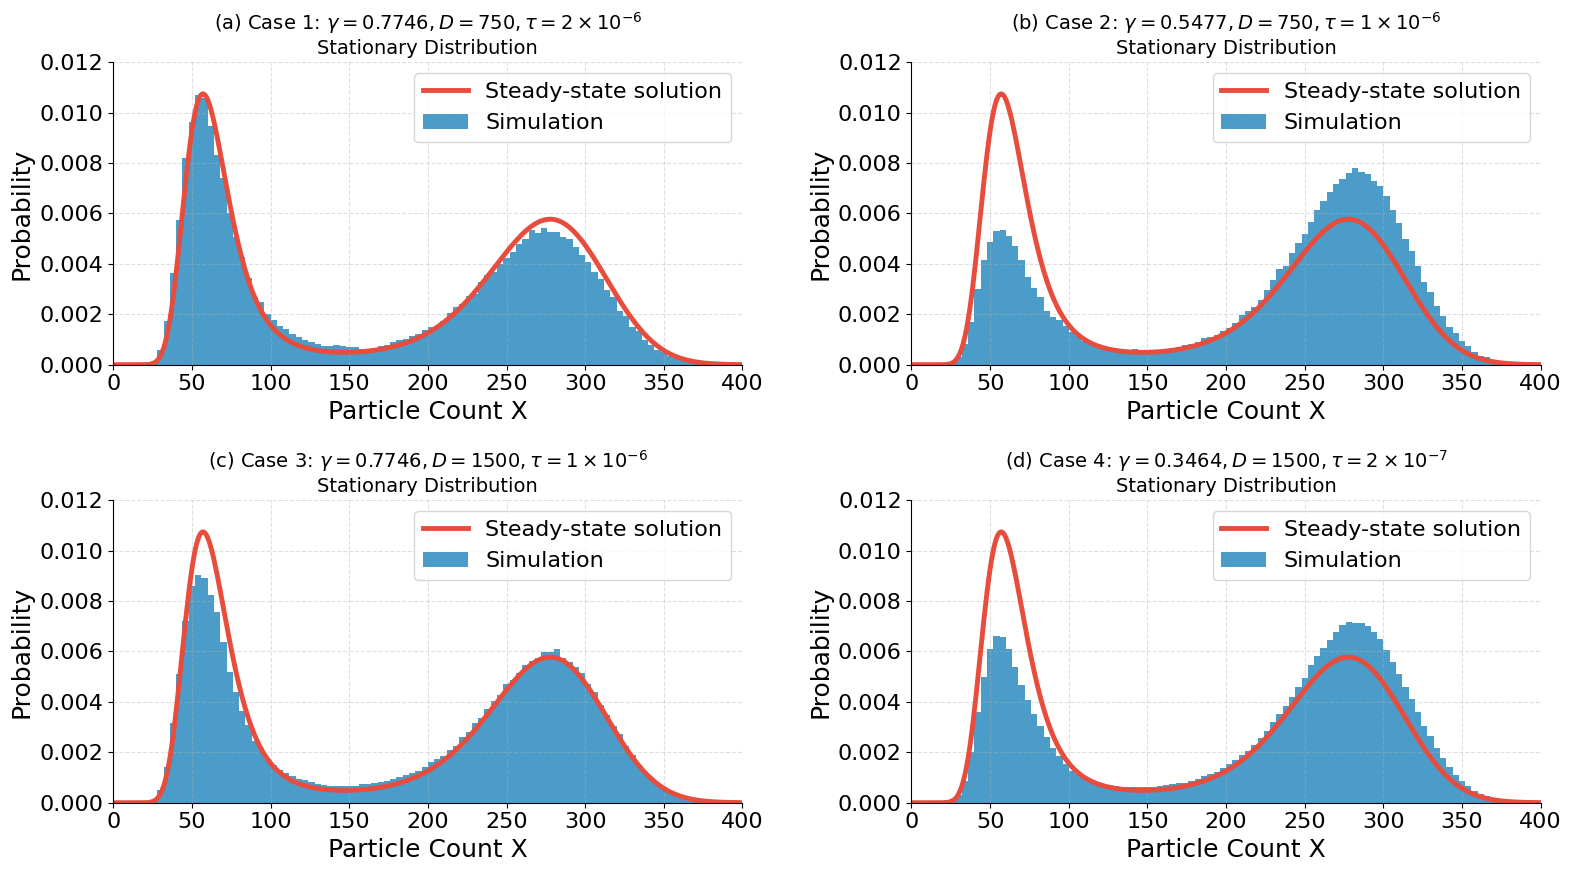

In [14]:

# 2. DEFINE YOUR THREE FOLDERS HERE
# (These should be the names of the folders inside 'simulation_data/well_mixed_data/')
folders = [
    "homo_kp_tf_24.0_DX2_750_tau_2e-06",   # e.g., "full_model_..._tau5e-7"
    "homo_tf_24.0_D_750.0",
    "homo_tf_24.0_D_1500.0", 
    "homo_tf_24.0_D_1500.0_tau_2e-07"
]

# Split the strings to allow the \n to actually work as a line break!
# labels = [
#     r"(a) Case 1: $\gamma=0.7746,$" + "\n" + r"$D=750, \tau=2 \times 10^{-6}$",
#     r"(b) Case 2: $\gamma=0.5477,$" + "\n" + r"$D=750, \tau=1 \times 10^{-6}$",
#     r"(c) Case 3: $\gamma=0.7746,$" + "\n" + r"$D=1500, \tau=1\times 10^{-6}$",
#     r"(d) Case 4: $\gamma=0.3464,$" + "\n" + r"$D=1500, \tau=2 \times 10^{-7}$"
# ]
labels = [
    r"(a) Case 1: $\gamma=0.7746,D=750, \tau=2 \times 10^{-6}$",
    r"(b) Case 2: $\gamma=0.5477,D=750, \tau=1 \times 10^{-6}$",
    r"(c) Case 3: $\gamma=0.7746,D=1500, \tau=1\times 10^{-6}$",
    r"(d) Case 4: $\gamma=0.3464,D=1500, \tau=2 \times 10^{-7}$"
]
# 3. SETUP THE FIGURE
# Increased the width from 12 to 16 so the 4 columns don't squish together
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(16, 9))
axs_flat = axs.flatten()

color_x = "#0072B2"
color_x2 = "#D55E00"
num_plot_traj = 100
print(axs)
plt.rcParams.update({
    'font.size': 16,          # General font size
    'axes.titlesize': 20,     # Subtitles & top case labels
    'axes.labelsize': 22,     # Axis labels (X and Y labels)
    'xtick.labelsize': 16,    # X-axis tick numbers
    'ytick.labelsize': 16,    # Y-axis tick numbers
    'legend.fontsize': 16     # Legend font size
})
for col, (folder, label) in enumerate(zip(folders, labels)):
    
    file_str = "spatial_data/" + folder
    print(f"Loading data from: {file_str}")
    
    # Load data
    trajectories, combined_data, _,_, metadata = load_spatial_full_data(file_str=file_str)
    
    if not trajectories:
        print(f"  -> Skipping {folder} - no data found.")
        continue

    tau = metadata['timestep']
    # Downsample data slightly to speed up plotting/density calculations
    slice_val = max(1, int(1e-2/tau))

    # # ==========================================
    # # --- TOP ROW: Trajectory ---
    # # ==========================================
    # ax_traj = axs[0, col]
    # traj = trajectories[0] # Just plot the first trajectory as an example
    # x_time = traj['timescale']
    # y_x = traj['species_log']['X']
    
    # ax_traj.plot(x_time, y_x, color=color_x, label='X', drawstyle='steps-post', alpha=0.9, linewidth=1.5)
    # ax_traj.fill_between(x_time, y_x, color=color_x, step='post', alpha=0.1)
    
    # # If full model, plot X2 as well
    # if 'X2' in traj['species_log']:
    #     y_x2 = traj['species_log']['X2']
    #     ax_traj.plot(x_time, y_x2, color=color_x2, label='$X_2$', drawstyle='steps-post', alpha=0.9, linewidth=1.5)
    #     ax_traj.fill_between(x_time, y_x2, color=color_x2, step='post', alpha=0.1)
        
    # ax_traj.set_title(f"{label}\nTrajectory", fontsize=14)
    # ax_traj.set_xlabel('Time')
    # ax_traj.set_ylabel('Particle Count')
    # ax_traj.legend(loc='upper right')
    # ax_traj.grid(True, linestyle='--', alpha=0.4)
    # ax_traj.spines['top'].set_visible(False)
    # ax_traj.spines['right'].set_visible(False)
    # ax_traj.set_xlim(left=x_time[0])
    # ax_traj.set_ylim(0, 430)

    # ==========================================
    # --- BOTTOM ROW: Distribution ---
    # ==========================================
    ax_dist = axs_flat[col] # axs[col]#[0, col]
    if num_plot_traj < len(trajectories):
        trajectories = random.sample(trajectories, num_plot_traj)
        print(f"the number of trajs is {len(trajectories)}")
        # overwrite the combined_data to ONLY include the sampled trajectories
        combined_data_X = np.concatenate([t['species_log']['X'] for t in trajectories])
        if 'X2' in trajectories[0]['species_log']:
            combined_data_X2 = np.concatenate([t['species_log']['X2'] for t in trajectories])
        else:
            combined_data_X2 = np.array([])
    else:
        print(f"the number of trajs is {len(trajectories)}")
        combined_data_X = combined_data['X']
        combined_data_X2 = combined_data.get('X2', np.array([]))
        
    rates = count_transitions_hysteresis(trajectories, tau)
    print(f"{label}")
    print(f"  Mean switching rate: {np.mean(rates):.4f} transitions/time")
    print(f"  Std:                 {np.std(rates):.4f}")
    print()
    valid_idx = combined_data_X > 0
    safe_X = combined_data_X[valid_idx]
    safe_X2 = combined_data_X2[valid_idx]   
    # Calculate ratio: (X2 * Vol) / (X^2)
    ratio_1 = np.mean(safe_X2 * 8.0 / (safe_X**2)) * 10**3
    print(f"----- Test: the ratio is {ratio_1:.6f} × 10⁻³ -----")
    
    upper_bound = get_pretty_upper_bound(combined_data_X)
    
    bin_width = 4.0
    band_width = 2.5714 # Project default bandwidth
    
    hist_bin, density_hist = hist_np(combined_data_X, upper_bound, bin_width)
    x_axis_plot, kde_X = kde_sk(combined_data_X, upper_bound, band_width)
    
    # Analytical Curve calculation
    macrorates = metadata['macrorates']
    a = metadata['a']
    b = metadata['b']
    box_shape = metadata['box_shape']
    vol = np.prod(box_shape)
    # If full model, convert macroscopic l to k to get the Schlögl analytical curve
    if len(combined_data) > 1:
        macrorates_k = calculate_k_from_l(macrorates)
    else:
        macrorates_k = macrorates
        
    p_states, stat_dist = get_analytical_curve(upper_bound, macrorates_k, a, b, vol)
    W_d = wasserstein_distance(p_states, x_axis_plot, stat_dist, kde_X)
    print(f"the current group is: {metadata}")
    print(f"the wasserstein distance is: {W_d}")

    ax_dist.bar(hist_bin, density_hist, width=bin_width, color= "#0072B2", alpha=0.7, label='Simulation') #edgecolor='white',
    # ax_dist.plot(x_axis_plot, kde_X, color="#8ab41f", linewidth=2.5, label='KDE')
    ax_dist.plot(p_states, stat_dist, color='#e74c3c', linewidth=3.5, label='Steady-state solution')

    ax_dist.set_title(f"{label}\nStationary Distribution", fontsize=14)
    ax_dist.set_xlabel('Particle Count X')
    ax_dist.set_ylabel('Probability')
    ax_dist.set_xlim(0, upper_bound)
    ax_dist.set_ylim(0, 0.012)
    ax_dist.legend(loc='upper right')
    ax_dist.grid(True, linestyle='--', alpha=0.4)
    ax_dist.spines['top'].set_visible(False)
    ax_dist.spines['right'].set_visible(False)

# Add a super title for the whole figure
# fig.suptitle("Enforcing Time-Scale Separation in the Full Reaction Network", fontsize=18, y=0.98, fontweight='bold')
fig.tight_layout(w_pad=2.0) # Forces horizontal padding between the subplots
# Save the figure as a high-res image suitable for a thesis
# plt.savefig("time_scale_separation.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [15]:
def check_conditional_keq(trajectories, vol=8.0, low_thresh=100, high_thresh=200):
    keq_low_list = []
    keq_high_list = []
    
    for traj in trajectories:
        x = traj['species_log']['X']
        if 'X2' not in traj['species_log']:
            continue
        x2 = traj['species_log']['X2']
        
        # Valid indices (to avoid division by zero)
        valid = x > 0
        x_valid = x[valid]
        x2_valid = x2[valid]
        
        # Masks for low and high states
        mask_low = x_valid < low_thresh
        mask_high = x_valid > high_thresh
        
        # Calculate K_eq for low state
        if np.any(mask_low):
            # Ratio of the averages
            mean_X2_low = np.mean(x2_valid[mask_low])
            mean_Xsq_low = np.mean(x_valid[mask_low]**2)
            keq_low = (mean_X2_low * vol) / mean_Xsq_low
            keq_low_list.append(keq_low)
            
        # Calculate K_eq for high state
        if np.any(mask_high):
            mean_X2_high = np.mean(x2_valid[mask_high])
            mean_Xsq_high = np.mean(x_valid[mask_high]**2)
            keq_high = (mean_X2_high * vol) / mean_Xsq_high
            keq_high_list.append(keq_high)
            
    # Multiply by 10^3 for easy reading
    avg_keq_low = np.mean(keq_low_list) * 1000
    avg_keq_high = np.mean(keq_high_list) * 1000
    
    return avg_keq_low, avg_keq_high


In [16]:

# folders = [
#     'homo_tf_24.0_D_1500.0', 
# ]

# # Split the strings to allow the \n to actually work as a line break!
# labels = [
#     r"(a) Case 1: $\gamma=0.7746,$" + "\n" + r"$D=750, \tau=2 \times 10^{-6}$",
#     r"(b) Case 2: $\gamma=0.5477,$" + "\n" + r"$D=750, \tau=1 \times 10^{-6}$",
#     r"(c) Case 3: $\gamma=0.7746,$" + "\n" + r"$D=1500, \tau=1\times 10^{-6}$",
#     r"(d) Case 4: $\gamma=0.3464,$" + "\n" + r"$D=1500, \tau=2 \times 10^{-7}$"
# ]
# # 3. SETUP THE FIGURE
# # Increased the width from 12 to 16 so the 4 columns don't squish together
# # fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(16, 4.5))
# color_x = "#0072B2"
# color_x2 = "#D55E00"
# num_plot_traj = 100


# for col, (folder, label) in enumerate(zip(folders, labels)):
    
#     file_str = "spatial_data/" + folder
#     print(f"Loading data from: {file_str}")
    
#     # Load data
#     trajectories, combined_data, _,_, metadata = load_spatial_full_data(file_str=file_str)
    
#     if not trajectories:
#         print(f"  -> Skipping {folder} - no data found.")
#         continue

#     tau = metadata['timestep']
#     # Downsample data slightly to speed up plotting/density calculations
#     slice_val = max(1, int(1e-2/tau))

#     # ==========================================
#     # --- TOP ROW: Trajectory ---
#     # ==========================================
    
#     trajectories = random.sample(trajectories, num_plot_traj)
#     lth, htl = count_directional_transitions(trajectories, tau)
    
#     print("     low to high:")
#     print(f"  Mean switching rate: {np.mean(lth):.4f} transitions/time")
#     print(f"  Std:                 {np.std(lth):.4f}")
#     print("     high to low:")
#     print(f"  Mean switching rate: {np.mean(htl):.4f} transitions/time")
#     print(f"  Std:                 {np.std(htl):.4f}")
#     print()
#     # Run it for all your folders
#     print(f"{'K_eq Low (x10^-3)':<20} | {'K_eq High (x10^-3)':<20}")
#     print("-" * 60)

#     k_low, k_high = check_conditional_keq(trajectories)
#     # Just printing the first word of the label for compactness (e.g. "Case 1")
#     # short_label = label.split('\n')[0].replace(r'(a) ', '').replace(r'(b) ', '').replace(r'(c) ', '').replace(r'(d) ', '')
#     print(f"{k_low:<20.4f} | {k_high:<20.4f}")
#     # trajectories = random.sample(trajectories, num_plot_traj)
#     # for i in range(num_plot_traj):
#     #     ax_traj = axs[i]
#     #     traj = trajectories[i] # Just plot the first trajectory as an example
#     #     x_time = traj['timescale'] * tau
#     #     y_x = traj['species_log']['X']
        
#     #     ax_traj.plot(x_time, y_x, color=color_x, label='X', drawstyle='steps-post', alpha=0.9, linewidth=1.5)
#     #     ax_traj.fill_between(x_time, y_x, color=color_x, step='post', alpha=0.1)
        
#     #     # If full model, plot X2 as well
#     #     if 'X2' in traj['species_log']:
#     #         y_x2 = traj['species_log']['X2']
#     #         ax_traj.plot(x_time, y_x2, color=color_x2, label='$X_2$', drawstyle='steps-post', alpha=0.9, linewidth=1.5)
#     #         ax_traj.fill_between(x_time, y_x2, color=color_x2, step='post', alpha=0.1)
        
#     #     ax_traj.set_title(f"Trajectory {i+1}", fontsize=14)
#     #     ax_traj.set_xlabel('Time')
#     #     ax_traj.set_ylabel('Particle Count')
#     #     ax_traj.legend(loc='upper right')
#     #     ax_traj.grid(True, linestyle='--', alpha=0.4)
#     #     ax_traj.spines['top'].set_visible(False)
#     #     ax_traj.spines['right'].set_visible(False)
#     #     ax_traj.set_xlim(left=x_time[0])
#     #     ax_traj.set_ylim(0, 430)

#     # ==========================================
#     # --- BOTTOM ROW: Distribution ---
#     # ==========================================
#     # ax_dist = axs[col]#[0, col]
#     # if num_plot_traj < len(trajectories):
#     #     trajectories = random.sample(trajectories, num_plot_traj)
#     #     print(f"the number of trajs is {len(trajectories)}")
#     #     # overwrite the combined_data to ONLY include the sampled trajectories
#     #     combined_data_X = np.concatenate([t['species_log']['X'] for t in trajectories])
#     #     if 'X2' in trajectories[0]['species_log']:
#     #         combined_data_X2 = np.concatenate([t['species_log']['X2'] for t in trajectories])
#     #     else:
#     #         combined_data_X2 = np.array([])
#     # else:
#     #     print(f"the number of trajs is {len(trajectories)}")
#     #     combined_data_X = combined_data['X']
#     #     combined_data_X2 = combined_data.get('X2', np.array([]))

#     # # combined_data_X = combined_data['X'][::slice_val]
#     # upper_bound = get_pretty_upper_bound(combined_data_X)
    
#     # bin_width = 4.0
#     # band_width = 2.5714 # Project default bandwidth
    
#     # hist_bin, density_hist = hist_np(combined_data_X, upper_bound, bin_width)
#     # x_axis_plot, kde_X = kde_sk(combined_data_X, upper_bound, band_width)
    
#     # # Analytical Curve calculation
#     # macrorates = metadata['macrorates']
#     # a = metadata['a']
#     # b = metadata['b']
#     # box_shape = metadata['box_shape']
#     # vol = np.prod(box_shape)
#     # # If full model, convert macroscopic l to k to get the Schlögl analytical curve
#     # if len(combined_data) > 1:
#     #     macrorates_k = calculate_k_from_l(macrorates)
#     # else:
#     #     macrorates_k = macrorates
        
#     # p_states, stat_dist = get_analytical_curve(upper_bound, macrorates_k, a, b, vol)
#     # W_d = wasserstein_distance(p_states, x_axis_plot, stat_dist, kde_X)
#     # print(f"the current group is: {metadata}")
#     # print(f"the wasserstein distance is: {W_d}")

#     # ax_dist.bar(hist_bin, density_hist, width=bin_width, color= "#0072B2", alpha=0.7, label='Simulation') #edgecolor='white',
#     # # ax_dist.plot(x_axis_plot, kde_X, color='#1f77b4', linewidth=2.5, label='KDE')
#     # ax_dist.plot(p_states, stat_dist, color='#e74c3c', linewidth=3.5, label='Analytical Schlögl')

#     # ax_dist.set_title(f"{label}\nStationary Distribution", fontsize=14)
#     # ax_dist.set_xlabel('Particle Count X')
#     # ax_dist.set_ylabel('Probability')
#     # ax_dist.set_xlim(0, upper_bound)
#     # ax_dist.set_ylim(0, 0.012)
#     # ax_dist.legend(loc='upper right')
#     # ax_dist.grid(True, linestyle='--', alpha=0.4)
#     # ax_dist.spines['top'].set_visible(False)
#     # ax_dist.spines['right'].set_visible(False)

# # Add a super title for the whole figure
# # fig.suptitle("Enforcing Time-Scale Separation in the Full Reaction Network", fontsize=18, y=0.98, fontweight='bold')
# # fig.tight_layout(w_pad=2.0) # Forces horizontal padding between the subplots
# # Save the figure as a high-res image suitable for a thesis
# # plt.savefig("time_scale_separation.pdf", dpi=300, bbox_inches='tight')
# # plt.show()

In [17]:

# folders = [
#     "homo_tf_24.0_D_1500.0", 
# ]

# # Split the strings to allow the \n to actually work as a line break!
# labels = [
#     r"(a) Case 1: $\gamma=0.7746,$" + "\n" + r"$D=750, \tau=2 \times 10^{-6}$",
#     r"(b) Case 2: $\gamma=0.5477,$" + "\n" + r"$D=750, \tau=1 \times 10^{-6}$",
#     r"(c) Case 3: $\gamma=0.7746,$" + "\n" + r"$D=1500, \tau=1\times 10^{-6}$",
#     r"(d) Case 4: $\gamma=0.3464,$" + "\n" + r"$D=1500, \tau=2 \times 10^{-7}$"
# ]
# # 3. SETUP THE FIGURE
# # Increased the width from 12 to 16 so the 4 columns don't squish together
# fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(16, 4.5))
# color_x = "#0072B2"
# color_x2 = "#D55E00"
# num_plot_traj = 4


# for col, (folder, label) in enumerate(zip(folders, labels)):
    
#     file_str = "spatial_data/" + folder
#     print(f"Loading data from: {file_str}")
    
#     # Load data
#     trajectories, combined_data, _,_, metadata = load_spatial_full_data(file_str=file_str)
    
#     if not trajectories:
#         print(f"  -> Skipping {folder} - no data found.")
#         continue

#     tau = metadata['timestep']
#     # Downsample data slightly to speed up plotting/density calculations
#     slice_val = max(1, int(1e-2/tau))

#     # ==========================================
#     # --- TOP ROW: Trajectory ---
#     # ==========================================
    
#     trajectories = random.sample(trajectories, num_plot_traj)

#     for i in range(num_plot_traj):
#         ax_traj = axs[i]
#         traj = trajectories[i] # Just plot the first trajectory as an example
#         x_time = traj['timescale'] * tau
#         y_x = traj['species_log']['X']
        
#         ax_traj.plot(x_time, y_x, color=color_x, label='X', drawstyle='steps-post', alpha=0.9, linewidth=1.5)
#         ax_traj.fill_between(x_time, y_x, color=color_x, step='post', alpha=0.1)
        
#         # If full model, plot X2 as well
#         if 'X2' in traj['species_log']:
#             y_x2 = traj['species_log']['X2']
#             ax_traj.plot(x_time, y_x2, color=color_x2, label='$X_2$', drawstyle='steps-post', alpha=0.9, linewidth=1.5)
#             ax_traj.fill_between(x_time, y_x2, color=color_x2, step='post', alpha=0.1)
        
#         ax_traj.set_title(f"Trajectory {i+1}", fontsize=14)
#         ax_traj.set_xlabel('Time')
#         ax_traj.set_ylabel('Particle Count')
#         ax_traj.legend(loc='upper right')
#         ax_traj.grid(True, linestyle='--', alpha=0.4)
#         ax_traj.spines['top'].set_visible(False)
#         ax_traj.spines['right'].set_visible(False)
#         ax_traj.set_xlim(left=x_time[0])
#         ax_traj.set_ylim(0, 430)

#     # ==========================================
#     # --- BOTTOM ROW: Distribution ---
#     # ==========================================
#     # ax_dist = axs[col]#[0, col]
#     # if num_plot_traj < len(trajectories):
#     #     trajectories = random.sample(trajectories, num_plot_traj)
#     #     print(f"the number of trajs is {len(trajectories)}")
#     #     # overwrite the combined_data to ONLY include the sampled trajectories
#     #     combined_data_X = np.concatenate([t['species_log']['X'] for t in trajectories])
#     #     if 'X2' in trajectories[0]['species_log']:
#     #         combined_data_X2 = np.concatenate([t['species_log']['X2'] for t in trajectories])
#     #     else:
#     #         combined_data_X2 = np.array([])
#     # else:
#     #     print(f"the number of trajs is {len(trajectories)}")
#     #     combined_data_X = combined_data['X']
#     #     combined_data_X2 = combined_data.get('X2', np.array([]))

#     # # combined_data_X = combined_data['X'][::slice_val]
#     # upper_bound = get_pretty_upper_bound(combined_data_X)
    
#     # bin_width = 4.0
#     # band_width = 2.5714 # Project default bandwidth
    
#     # hist_bin, density_hist = hist_np(combined_data_X, upper_bound, bin_width)
#     # x_axis_plot, kde_X = kde_sk(combined_data_X, upper_bound, band_width)
    
#     # # Analytical Curve calculation
#     # macrorates = metadata['macrorates']
#     # a = metadata['a']
#     # b = metadata['b']
#     # box_shape = metadata['box_shape']
#     # vol = np.prod(box_shape)
#     # # If full model, convert macroscopic l to k to get the Schlögl analytical curve
#     # if len(combined_data) > 1:
#     #     macrorates_k = calculate_k_from_l(macrorates)
#     # else:
#     #     macrorates_k = macrorates
        
#     # p_states, stat_dist = get_analytical_curve(upper_bound, macrorates_k, a, b, vol)
#     # W_d = wasserstein_distance(p_states, x_axis_plot, stat_dist, kde_X)
#     # print(f"the current group is: {metadata}")
#     # print(f"the wasserstein distance is: {W_d}")

#     # ax_dist.bar(hist_bin, density_hist, width=bin_width, color= "#0072B2", alpha=0.7, label='Simulation') #edgecolor='white',
#     # # ax_dist.plot(x_axis_plot, kde_X, color='#1f77b4', linewidth=2.5, label='KDE')
#     # ax_dist.plot(p_states, stat_dist, color='#e74c3c', linewidth=3.5, label='Analytical Schlögl')

#     # ax_dist.set_title(f"{label}\nStationary Distribution", fontsize=14)
#     # ax_dist.set_xlabel('Particle Count X')
#     # ax_dist.set_ylabel('Probability')
#     # ax_dist.set_xlim(0, upper_bound)
#     # ax_dist.set_ylim(0, 0.012)
#     # ax_dist.legend(loc='upper right')
#     # ax_dist.grid(True, linestyle='--', alpha=0.4)
#     # ax_dist.spines['top'].set_visible(False)
#     # ax_dist.spines['right'].set_visible(False)

# # Add a super title for the whole figure
# # fig.suptitle("Enforcing Time-Scale Separation in the Full Reaction Network", fontsize=18, y=0.98, fontweight='bold')
# fig.tight_layout(w_pad=2.0) # Forces horizontal padding between the subplots
# # Save the figure as a high-res image suitable for a thesis
# # plt.savefig("time_scale_separation.pdf", dpi=300, bbox_inches='tight')
# plt.show()

In [18]:
# homo_kp_tf_24.0_DX2_3000_tau_5e-07
# homo_kp_tf_24.0_DX2_750_tau_2e-06